# Proyecto Final - Mineria de Datos en Python (Cancer)

**Dataset:** `Cancer_Data.csv` (Breast Cancer Wisconsin Diagnostic)

## Objetivo general
Este notebook aplica los temas principales de la materia al dataset Cancer_Data.csv.

El objetivo es estudiar el diagnostico de cancer desde varias miradas: preparacion y calidad de datos, analisis exploratorio, modelos supervisados, modelos no supervisados, PCA, reglas de asociacion y comparacion final de resultados.

La explicacion esta escrita para una exposicion academica: primero se muestra que se hizo, luego por que se hizo y finalmente como se interpreta el resultado.

## 1. Comprensión del problema

El problema principal es **clasificacion binaria**: identificar si un tumor es maligno (`M`) o benigno (`B`).

### Contexto tecnico
- Un **falso negativo** (predecir benigno cuando es maligno) tiene alto costo clinico.
- Por ello se priorizan **recall** y **F1** ademas de accuracy.

### Alcance
- Clasificacion supervisada con comparacion sin PCA vs con PCA (5 componentes), siguiendo la segunda entrega.
- Regresion sobre `area_worst` para cumplir la rubrica de modelos de regresion.
- Clustering no supervisado con silhouette y Dunn.


In [1]:
# Librerias
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
N_PCA = 5
sns.set_theme(style='whitegrid')
np.random.seed(RANDOM_STATE)

# Contenedores globales para comparacion final
resultados_clasificacion = []
resultados_regresion = []
resultados_clustering = []

print('Librerias cargadas.')


Librerias cargadas.


## 2. Carga del dataset

Se carga el CSV y se estandarizan nombres de columnas (`strip`, sin comillas, espacios a `_`).


## 3. Diccionario de variables
Descripción de cada variable presente en el conjunto de datos.

In [2]:
# Ruta compatible con repo local y Colab
for candidate in [Path('Cancer_Data.csv'), Path('../Cancer_Data.csv')]:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError('No se encontro Cancer_Data.csv')

df = pd.read_csv(DATA_PATH)
df.columns = (
    df.columns.str.strip()
      .str.replace('"', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

print('Shape:', df.shape)
df.head()


Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
diccionario = pd.DataFrame({
    'variable': df.columns,
    'tipo_dato': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'n_unicos': [df[c].nunique() for c in df.columns]
})
diccionario.head(15)


,variable,tipo_dato,nulos,n_unicos
0,id,int64,0,569
1,diagnosis,str,0,2
2,radius_mean,float64,0,456
3,texture_mean,float64,0,479
4,perimeter_mean,float64,0,522
5,area_mean,float64,0,539
6,smoothness_mean,float64,0,474
7,compactness_mean,float64,0,537
8,concavity_mean,float64,0,537
9,concave_points_mean,float64,0,542


## 4. Calidad de datos

Se revisan nulos, duplicados, tipos y outliers (IQR).


In [4]:
resumen_calidad = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'porcentaje_nulos': (df.isna().mean() * 100).round(2)
})
print('Duplicados exactos:', df.duplicated().sum())
resumen_calidad.head(20)


Duplicados exactos: 0


,tipo_dato,nulos,porcentaje_nulos
id,int64,0,0.0
diagnosis,str,0,0.0
radius_mean,float64,0,0.0
texture_mean,float64,0,0.0
perimeter_mean,float64,0,0.0
area_mean,float64,0,0.0
smoothness_mean,float64,0,0.0
compactness_mean,float64,0,0.0
concavity_mean,float64,0,0.0
concave_points_mean,float64,0,0.0


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_stats = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_stats.append((col, n_out, round(100 * n_out / len(df), 2)))

pd.DataFrame(outlier_stats, columns=['variable', 'n_outliers', 'pct_outliers']).sort_values('n_outliers', ascending=False).head(12)


,variable,n_outliers,pct_outliers
0,id,81,14.24
14,area_se,65,11.42
11,radius_se,38,6.68
13,perimeter_se,38,6.68
24,area_worst,35,6.15
15,smoothness_se,30,5.27
20,fractal_dimension_se,28,4.92
16,compactness_se,28,4.92
19,symmetry_se,27,4.75
4,area_mean,25,4.39


**Decisiones de calidad:**
- Sin nulos relevantes: no se imputa artificialmente.
- Outliers clinicos se conservan; se usara escalado en modelos sensibles.
- `id` se elimina en modelado por no aportar señal predictiva.


## 5. Análisis Exploratorio de Datos (EDA)


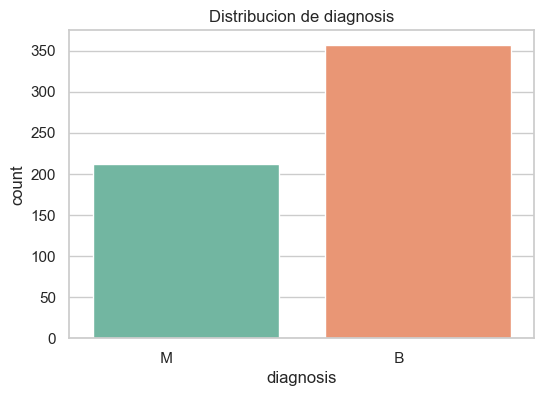

diagnosis
B              62.74
M              37.26
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribucion de diagnosis')
plt.show()
print(df['diagnosis'].value_counts(normalize=True).mul(100).round(2))


## 5.1Lectura Directa de los Datos
62.74% de las muestras corresponden a tumores Benignos (B).

37.26% de las muestras corresponden a tumores Malignos (M).

## 5.2 Histogramas

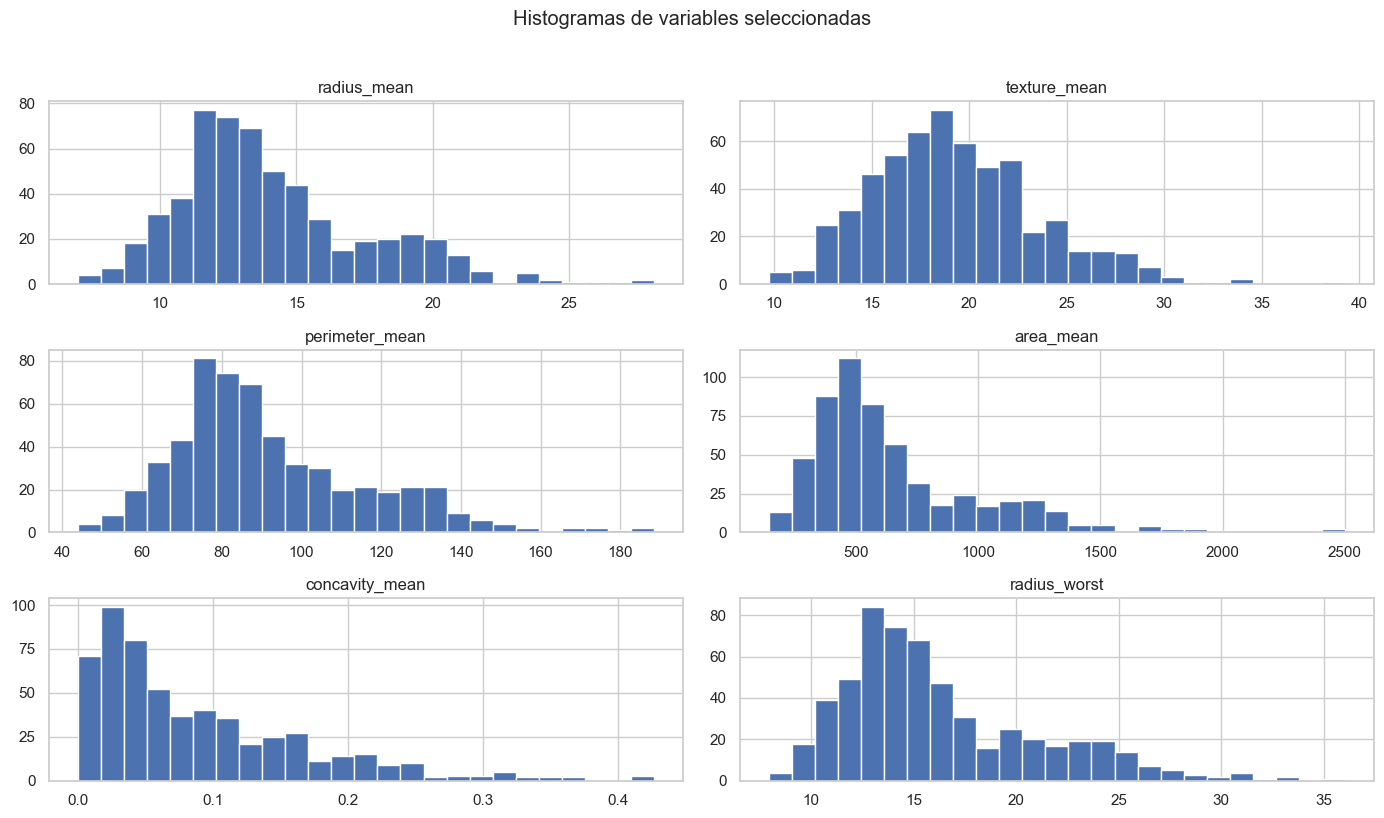

In [7]:
vars_hist = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'radius_worst']
df[vars_hist].hist(figsize=(14, 8), bins=25)
plt.suptitle('Histogramas de variables seleccionadas', y=1.02)
plt.tight_layout(); plt.show()


Los tumores benignos suelen ser más pequeños, simétricos y homogéneos. Por eso hay una gran acumulación de datos en valores bajos de radio, área y concavidad. En cambio, los tumores malignos tienden a crecer descontroladamente, mostrando células mucho más grandes, deformes y con alta concavidad.

## 5.3 Boxplot

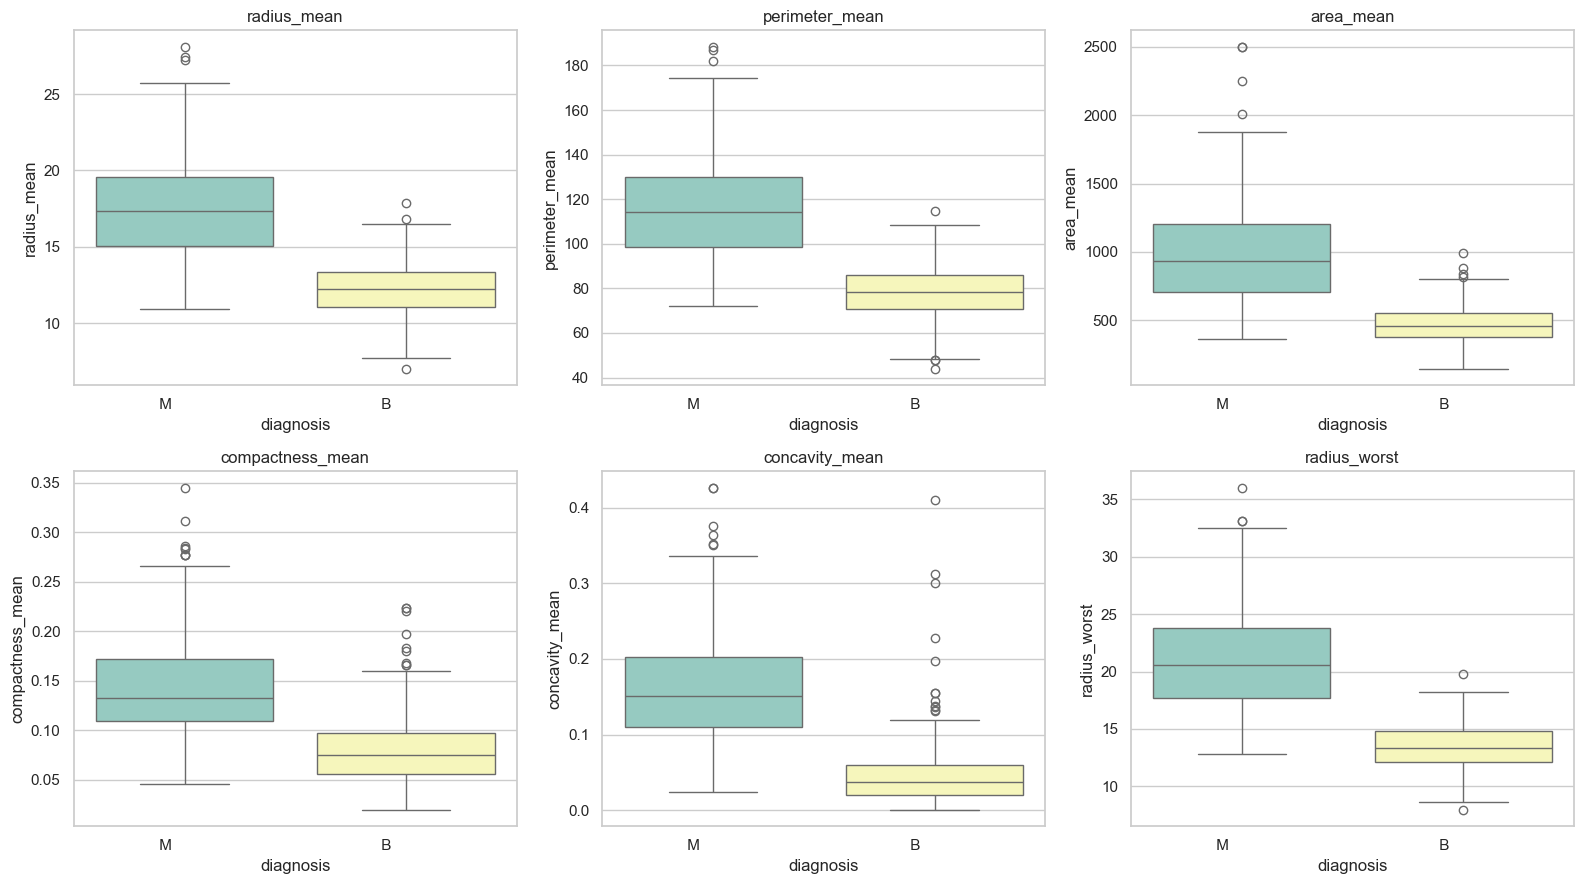

In [8]:
vars_box = ['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'radius_worst']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), vars_box):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette='Set3')
    ax.set_title(col)
plt.tight_layout(); plt.show()


Se observas radius_mean, perimeter_mean, area_mean y radius_worst, las cajas apenas se cruzan entre sí.

Se nota que la mediana de la clase Benigna (B) es sustancialmente más baja que la mediana de la clase Maligna (M).

Conclusión médica: Los núcleos de las células cancerígenas (M) son, por norma general, muchísimo más grandes en radio, perímetro y área que los de las células sanas o benignas (B). Esta clara separación significa que cualquier algoritmo de clasificación (como un árbol de decisión o SVM) va a usar estas variables como sus principales criterios de división.

compactness_mean y concavity_mean: Indicadores de Deformidad
La compacidad y la concavidad miden qué tan irregular y "arrugada" es la frontera de la célula.

En la clase Benigna (B), las cajas son muy compactas y aplastadas cerca de valores bajos. Esto confirma que las células benignas mantienen una estructura geométrica uniforme, lisa y esférica.

En la clase Maligna (M), las cajas se estiran enormemente hacia arriba. Esto demuestra la alta variabilidad morfológica del cáncer: las células malignas pierden el control de su forma, volviéndose extremadamente amorfas y rugosas.

## 5.4 Matriz de correlacion

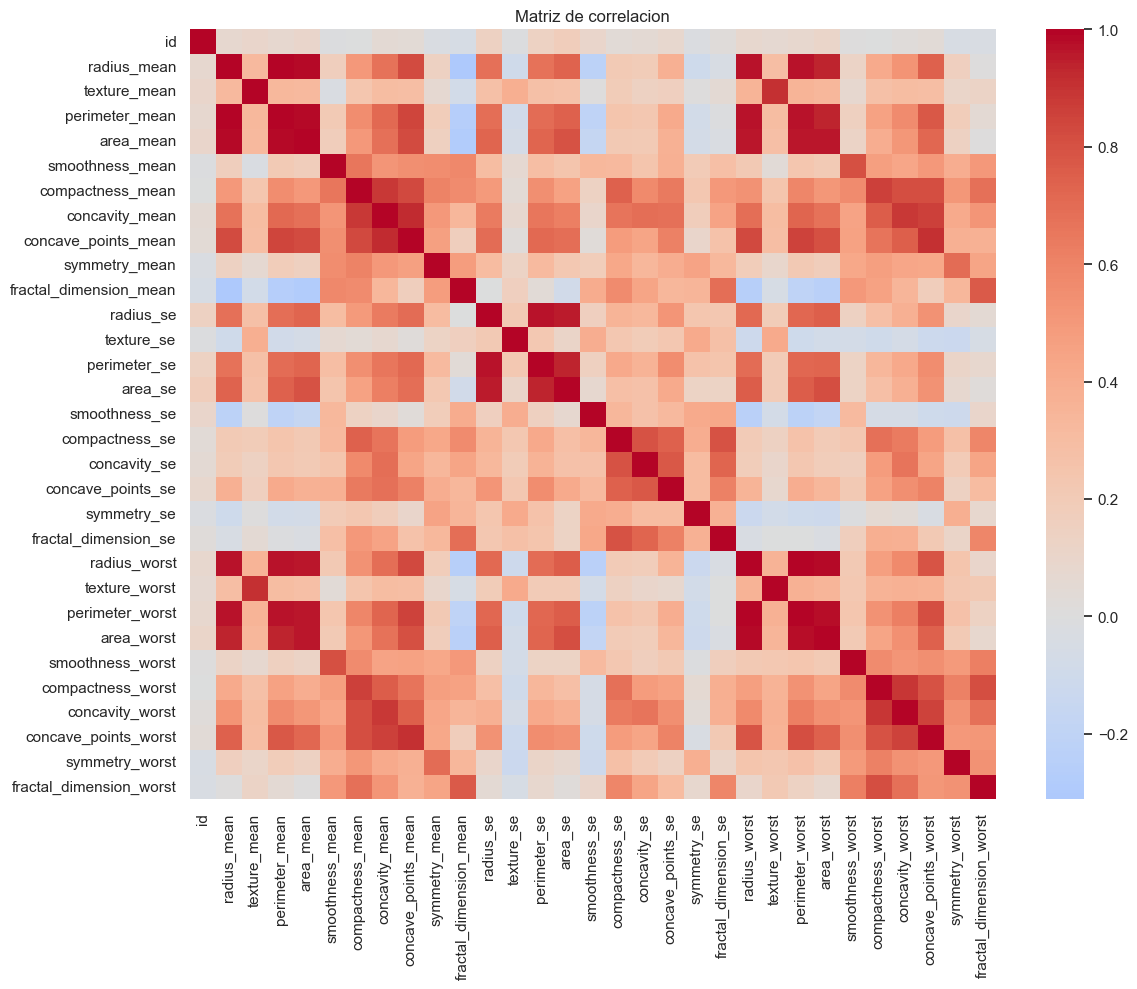

In [9]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlacion')
plt.show()


Grupo Geométrico Principal (mean): radius_mean, perimeter_mean y area_mean. Tienen una correlación casi perfecta de 1.0 entre ellas.

Grupo de Error Estándar (se): radius_se, perimeter_se y area_se. Miden la variabilidad física y también se mueven juntas.

Grupo de los Peores Escenarios (worst): radius_worst, perimeter_worst y area_worst.

**Interpretacion EDA:** variables de tamaño y concavidad separan parcialmente benigno/maligno; existe desbalance moderado y correlaciones altas entre features relacionadas.


## 5.5 Análisis multivariado
Debido a que el perfil Maligno está fuertemente correlacionado de forma interna (tamaño con tamaño, forma con forma), algoritmos basados en árboles de decisión (como Random Forest o XGBoost) o modelos de reducción de dimensionalidad (PCA) funcionarán excepcionalmente bien aquí. Podrán colapsar la redundancia de las variables físicas y concentrarse en la frontera donde los perfiles $M$ y $B$ se intersectan debido a los outliers.

## 6. Preparación de Datos

Siguiendo `segunda_entrega_16_05`, se define un pipeline comun:
1. Limpieza de `diagnosis` (`M=1`, `B=0`)
2. Eliminacion de `id`
3. Split estratificado 80/20
4. Escalado con `StandardScaler` sobre train
5. PCA con 5 componentes (reutilizable por cada modelo)


In [10]:
# Preparacion comun (clasificacion)
work = df.copy()
work['diagnosis'] = work['diagnosis'].astype(str).str.strip().str.upper()
work['diagnosis'] = work['diagnosis'].map({'M': 1, 'B': 0})

X = work.drop(columns=['diagnosis', 'id'], errors='ignore')
y = work['diagnosis']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_model = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Varianza acumulada PCA(5):', round(pca_model.explained_variance_ratio_.sum(), 4))


Train: (455, 30) Test: (114, 30)
Varianza acumulada PCA(5): 0.8494


In [11]:
# Funciones auxiliares de evaluacion

def evaluar_clasificacion(nombre, y_true, y_pred):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

def evaluar_regresion(nombre, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'modelo': nombre,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

def plot_matriz_confusion(y_true, y_pred, titulo):
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(titulo)
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

def registrar_clasificacion(fila):
    resultados_clasificacion.append(fila)
    return fila

print('Funciones auxiliares listas.')


Funciones auxiliares listas.


## 6.5) PCA base (5 componentes)

Se escogieron 5 comoponentes porque representan el 0.8494 de los datos

## 6.5.1 Loadings
La altura de las barras representa el peso (influencia) de cada variable en ese componente. Si la barra es positiva, la variable empuja el componente hacia arriba; si es negativa, lo empuja hacia abajo.

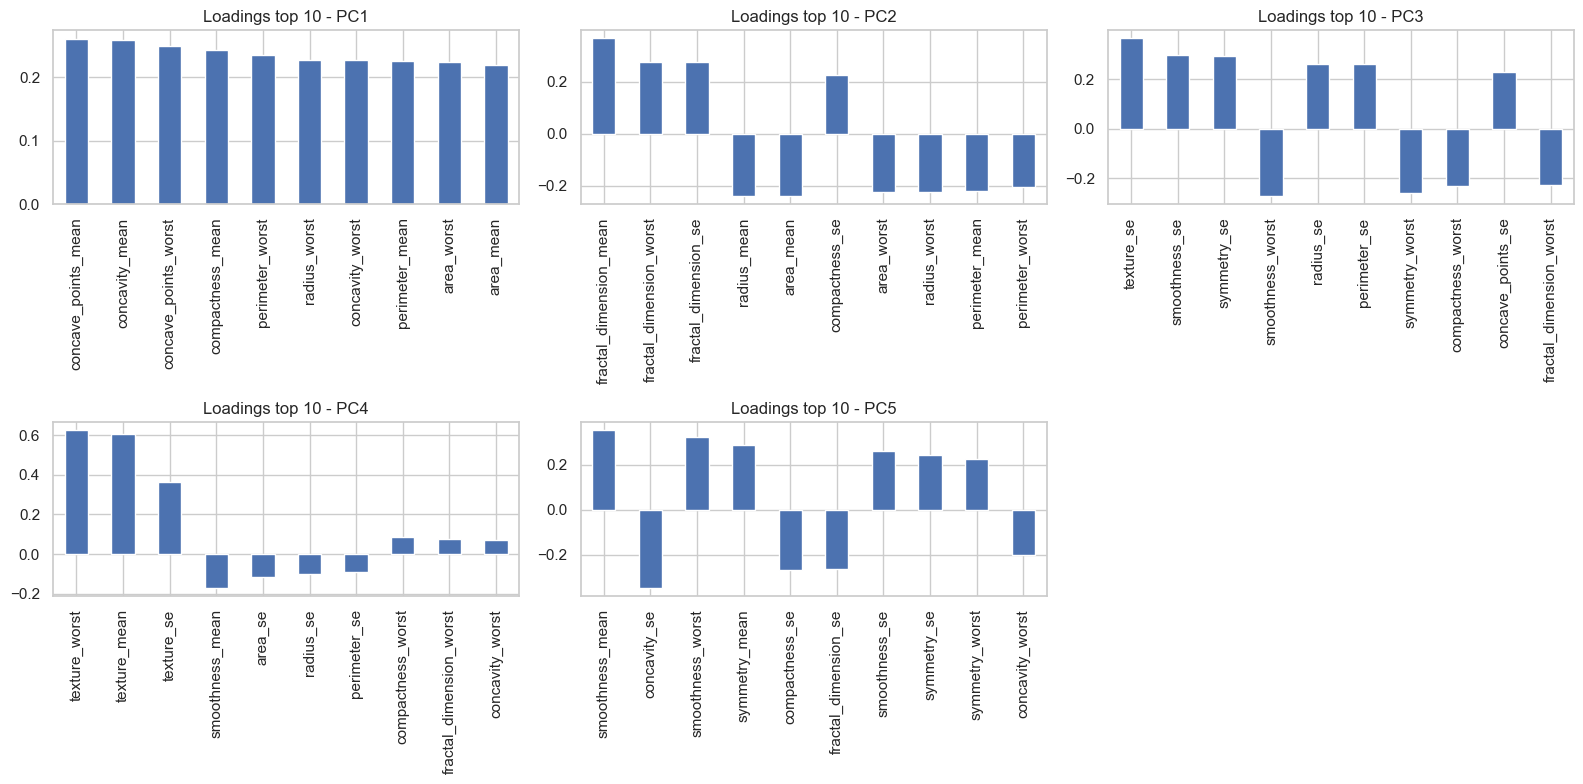

In [12]:
# Loadings (barras por componente)
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=[f'PC{i+1}' for i in range(N_PCA)],
    index=feature_names
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, ax in enumerate(axes.ravel()):
    if i < N_PCA:
        top = loadings[f'PC{i+1}'].reindex(loadings[f'PC{i+1}'].abs().sort_values(ascending=False).index).head(10)
        top.plot(kind='bar', ax=ax)
        ax.set_title(f'Loadings top 10 - PC{i+1}')
    else:
        ax.axis('off')
plt.tight_layout(); plt.show()


## 6.5.2 Biplot
Despues de reducir un espacio multidimensional complejo a solo dos ejes matemáticos, mapeando los tumores Benignos en azul ($0 = B$) y los Malignos en rojo ($1 = M$).Separación de Clases Excepcional: Los puntos azules se agrupan con mucha densidad hacia la izquierda (valores negativos de PC1), mientras que los rojos se expanden hacia la derecha (valores positivos de PC1). Hay una frontera diagonal natural muy limpia. Esto te asegura que modelos lineales (como una Regresión Logística o un SVM Lineal) van a tener un desempeño brutal en el entrenamiento.

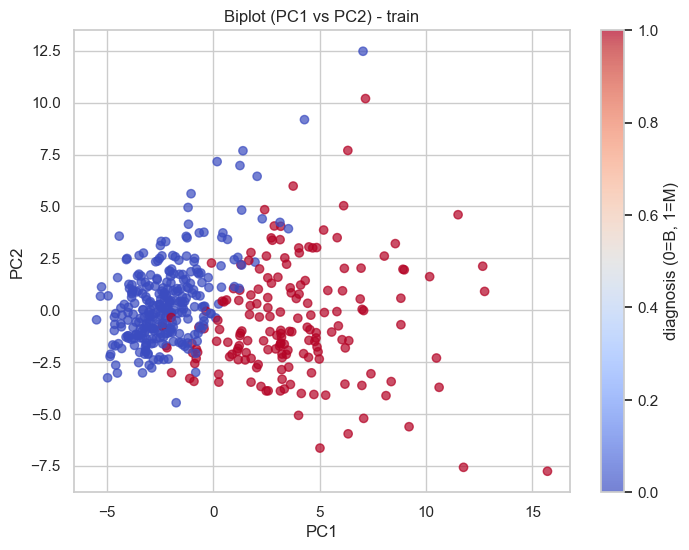

In [13]:
# Biplot simplificado (PC1 vs PC2)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Biplot (PC1 vs PC2) - train')
plt.colorbar(scatter, label='diagnosis (0=B, 1=M)')
plt.show()


## 6.5.3 ScreePlot
En un Scree Plot, verás que la curva cae drásticamente entre el PC1 y el PC2, y luego empieza a aplanarse gradualmente. A esto se le conoce como el "codo de la gráfica", por lo cual por eso se escogieron 5 componentes

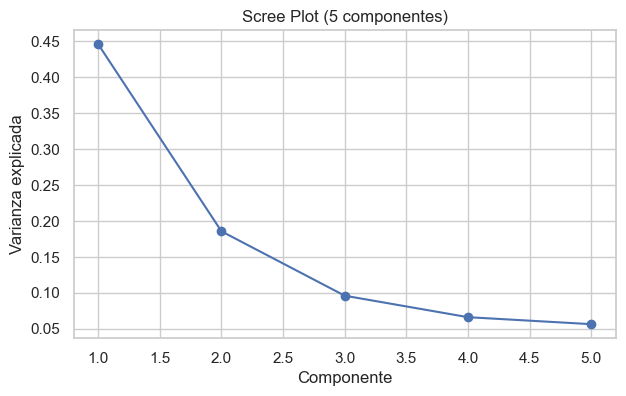

In [14]:
# Scree plot
var_ratio = pca_model.explained_variance_ratio_
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_ratio)+1), var_ratio, marker='o')
plt.xlabel('Componente'); plt.ylabel('Varianza explicada')
plt.title('Scree Plot (5 componentes)')
plt.grid(True)
plt.show()


## 7.1 Modelos Supervisados

### 7.1.1) Modelo: Regresion Logistica

**Guia metodologica:** `segunda_entrega_16_05/Regresion_PCA_Cancer.ipynb` y `Clases/04_colab_mineria_RL_.ipynb`

### Pasos de esta seccion
1. Entrenar sin PCA (datos escalados)
2. Entrenar con PCA (5 componentes)
3. Comparar metricas
4. Detectar overfitting (train vs test)
5. Matriz de confusion
6. Interpretar resultados


In [15]:
# 7.1 Regresion Logistica - Sin PCA
log_sin = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])
log_sin.fit(X_train, y_train)
pred_log_sin = log_sin.predict(X_test)
res_log_sin = evaluar_clasificacion('Logistica - Sin PCA', y_test, pred_log_sin)
registrar_clasificacion(res_log_sin)
pd.DataFrame([res_log_sin])


,modelo,accuracy,precision,recall,f1
0,Logistica - Sin PCA,0.964912,0.975,0.928571,0.95122


In [16]:
# 7.2 Regresion Logistica - Con PCA
log_pca = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_pca.fit(X_train_pca, y_train)
pred_log_pca = log_pca.predict(X_test_pca)
res_log_pca = evaluar_clasificacion('Logistica - Con PCA (5)', y_test, pred_log_pca)
registrar_clasificacion(res_log_pca)
pd.DataFrame([res_log_sin, res_log_pca])


,modelo,accuracy,precision,recall,f1
0,Logistica - Sin PCA,0.964912,0.97500,0.928571,0.951220
1,Logistica - Con PCA (5),0.973684,0.97561,0.952381,0.963855


In [17]:
# 7.3 Overfitting (train vs test) - Logistica sin PCA
log_fit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
]).fit(X_train, y_train)

train_pred = log_fit.predict(X_train)
test_pred = log_fit.predict(X_test)

overfit_log = pd.DataFrame([
    {'conjunto': 'Train', **evaluar_clasificacion('train', y_train, train_pred)},
    {'conjunto': 'Test', **evaluar_clasificacion('test', y_test, test_pred)}
])
overfit_log


,conjunto,modelo,accuracy,precision,recall,f1
0,Train,train,0.986813,1.000,0.964706,0.982036
1,Test,test,0.964912,0.975,0.928571,0.951220


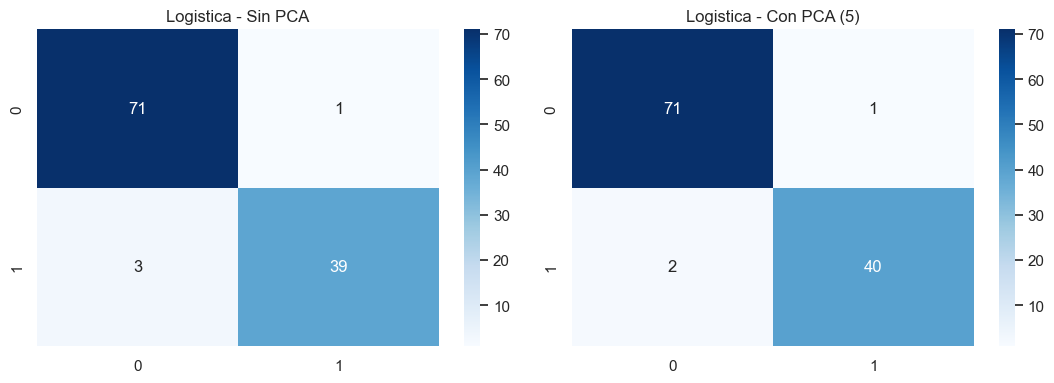

In [18]:
# 7.4 Matrices de confusion - Logistica
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(
    axes,
    [pred_log_sin, pred_log_pca],
    ['Sin PCA', 'Con PCA (5)']
):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Logistica - {title}')
plt.tight_layout(); plt.show()


**Interpretacion Logistica:** modelo lineal interpretable; si PCA reduce levemente metricas pero simplifica dimensionalidad, el trade-off depende del objetivo clinico (priorizar recall).


### 7.1.2) Modelo: KNN

**Guia metodologica:** `segunda_entrega_16_05/KNN_PCA_Cancer.ipynb`

### Pasos de esta seccion
1. Comparar KNN sin escalar vs escalado
2. Evaluar K=1..30 sin PCA y con PCA
3. Elegir K=5 (referencia de segunda entrega)
4. Matrices de confusion sin/con PCA


In [19]:
# 7.2.1 Impacto del escalado en KNN (K=5)
knn_unscaled = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)

comp_escalado = pd.DataFrame([
    evaluar_clasificacion('KNN sin escalar', y_test, knn_unscaled.predict(X_test)),
    evaluar_clasificacion('KNN con escalado', y_test, knn_scaled.predict(X_test_scaled))
])
comp_escalado


  File "C:\Users\julia\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\julia\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\julia\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\julia\AppData\Local\Python\pythoncore-3.14-64\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^

,modelo,accuracy,precision,recall,f1
0,KNN sin escalar,0.912281,0.970588,0.785714,0.868421
1,KNN con escalado,0.956140,0.974359,0.904762,0.938272


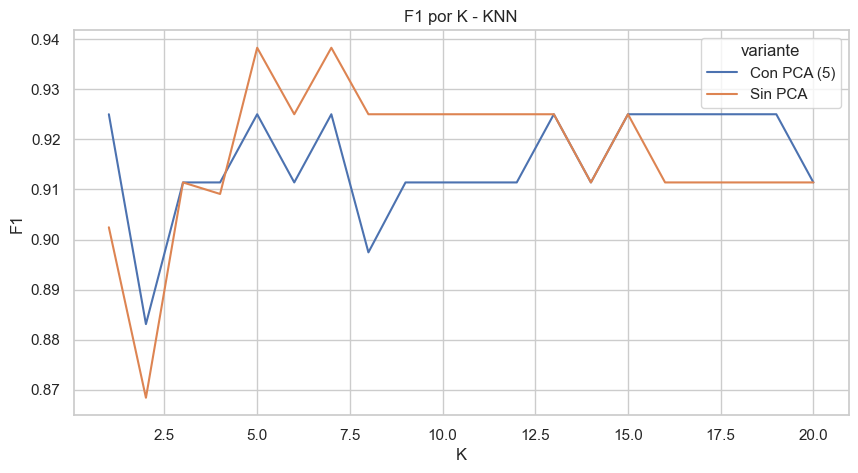

variante,Con PCA (5),Sin PCA
K,,
1,0.925000,0.902439
2,0.883117,0.868421
3,0.911392,0.911392
4,0.911392,0.909091
5,0.925000,0.938272


In [20]:
# 7.2.2 Evolucion de metricas por K (sin PCA vs con PCA)
k_values = range(1, 21)
rows = []
for k in k_values:
    m1 = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    p1 = m1.predict(X_test_scaled)
    rows.append({'K': k, 'variante': 'Sin PCA', **evaluar_clasificacion('tmp', y_test, p1)})

    m2 = KNeighborsClassifier(n_neighbors=k).fit(X_train_pca, y_train)
    p2 = m2.predict(X_test_pca)
    rows.append({'K': k, 'variante': 'Con PCA (5)', **evaluar_clasificacion('tmp', y_test, p2)})

knn_grid = pd.DataFrame(rows)
knn_pivot = knn_grid.pivot_table(index='K', columns='variante', values='f1')
knn_pivot.plot(figsize=(10, 5), title='F1 por K - KNN')
plt.ylabel('F1'); plt.grid(True); plt.show()
knn_pivot.head()


In [21]:
# 7.2.3 KNN final (K=5)
knn_sin = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
pred_knn_sin = knn_sin.predict(X_test_scaled)
res_knn_sin = registrar_clasificacion(evaluar_clasificacion('KNN - Sin PCA', y_test, pred_knn_sin))

knn_con = KNeighborsClassifier(n_neighbors=5).fit(X_train_pca, y_train)
pred_knn_con = knn_con.predict(X_test_pca)
res_knn_con = registrar_clasificacion(evaluar_clasificacion('KNN - Con PCA (5)', y_test, pred_knn_con))

pd.DataFrame([res_knn_sin, res_knn_con])


,modelo,accuracy,precision,recall,f1
0,KNN - Sin PCA,0.956140,0.974359,0.904762,0.938272
1,KNN - Con PCA (5),0.947368,0.973684,0.880952,0.925000


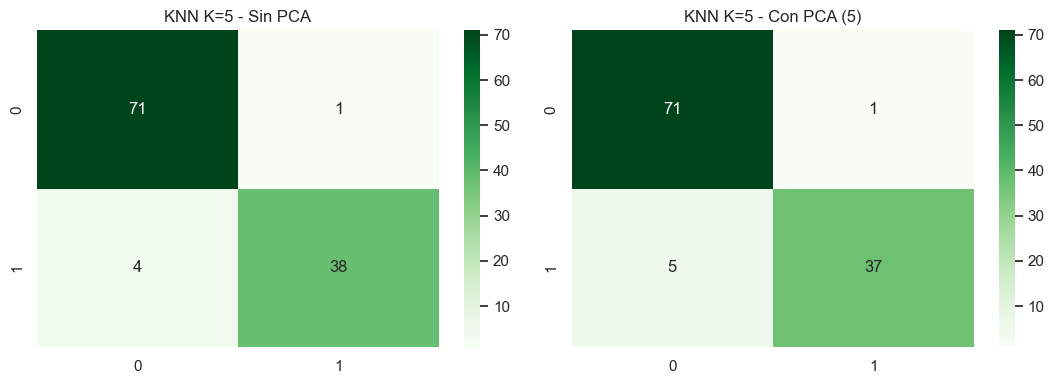

In [22]:
# 7.2.4 Matrices de confusion - KNN
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes, [pred_knn_sin, pred_knn_con], ['Sin PCA', 'Con PCA (5)']):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Greens', ax=ax)
    ax.set_title(f'KNN K=5 - {title}')
plt.tight_layout(); plt.show()


**Interpretacion KNN:** el escalado es indispensable; PCA puede acelerar y estabilizar, pero conviene validar si mejora F1/recall para K seleccionado.


### 7.1.3) Modelo: Arbol de Decision

**Guia metodologica:** `segunda_entrega_16_05/DecisionTree_PCA_Cancer.ipynb` y `Clases/05_Mineria_Datos_Arboles_Titanic.ipynb`

### Pasos de esta seccion
1. Busqueda simple de hiperparametros
2. Entrenar mejor configuracion sin/con PCA
3. Visualizar arbol (profundidad limitada)
4. Matrices de confusion


In [23]:
# 7.3.1 Busqueda de hiperparametros (submuestra de grilla)
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 2, 4]
}
rows_dt = []
for max_depth in param_grid['max_depth']:
    for min_samples_leaf in param_grid['min_samples_leaf']:
        params = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf, 'random_state': RANDOM_STATE}
        dt1 = DecisionTreeClassifier(**params).fit(X_train, y_train)
        p1 = dt1.predict(X_test)
        r1 = evaluar_clasificacion('Arbol sin PCA', y_test, p1)
        r1.update(params)
        rows_dt.append(r1)

        dt2 = DecisionTreeClassifier(**params).fit(X_train_pca, y_train)
        p2 = dt2.predict(X_test_pca)
        r2 = evaluar_clasificacion('Arbol con PCA', y_test, p2)
        r2.update(params)
        rows_dt.append(r2)

df_dt_search = pd.DataFrame(rows_dt).sort_values('f1', ascending=False)
df_dt_search.head(8)


,modelo,accuracy,precision,recall,f1,max_depth,min_samples_leaf,random_state
15,Arbol con PCA,0.956140,0.974359,0.904762,0.938272,7.0,2,42
7,Arbol con PCA,0.947368,0.973684,0.880952,0.925000,5.0,1,42
11,Arbol con PCA,0.947368,0.973684,0.880952,0.925000,5.0,4,42
23,Arbol con PCA,0.947368,0.973684,0.880952,0.925000,NaN,4,42
17,Arbol con PCA,0.947368,0.973684,0.880952,0.925000,7.0,4,42
21,Arbol con PCA,0.938596,0.926829,0.904762,0.915663,NaN,2,42
13,Arbol con PCA,0.938596,0.948718,0.880952,0.913580,7.0,1,42
12,Arbol sin PCA,0.938596,0.948718,0.880952,0.913580,7.0,1,42


poner un límite de profundidad en 7 evita que el árbol crezca de forma indefinida y memorice el ruido (lo que causaría sobreajuste). Además, exigir un min_samples_leaf = 2 obliga a que cada nodo terminal contenga al menos dos muestras, lo que actúa como un excelente regulador para suavizar las fronteras de decisión en las zonas donde las clases se solapan.

In [24]:
# 7.3.2 Arbol final (configuracion robusta)
best_params = {'max_depth': 5, 'min_samples_leaf': 2, 'random_state': RANDOM_STATE}
dt_sin = DecisionTreeClassifier(**best_params).fit(X_train, y_train)
pred_dt_sin = dt_sin.predict(X_test)
res_dt_sin = registrar_clasificacion(evaluar_clasificacion('Arbol - Sin PCA', y_test, pred_dt_sin))

dt_pca = DecisionTreeClassifier(**best_params).fit(X_train_pca, y_train)
pred_dt_pca = dt_pca.predict(X_test_pca)
res_dt_pca = registrar_clasificacion(evaluar_clasificacion('Arbol - Con PCA (5)', y_test, pred_dt_pca))

pd.DataFrame([res_dt_sin, res_dt_pca])


,modelo,accuracy,precision,recall,f1
0,Arbol - Sin PCA,0.912281,0.944444,0.809524,0.871795
1,Arbol - Con PCA (5),0.938596,0.948718,0.880952,0.913580


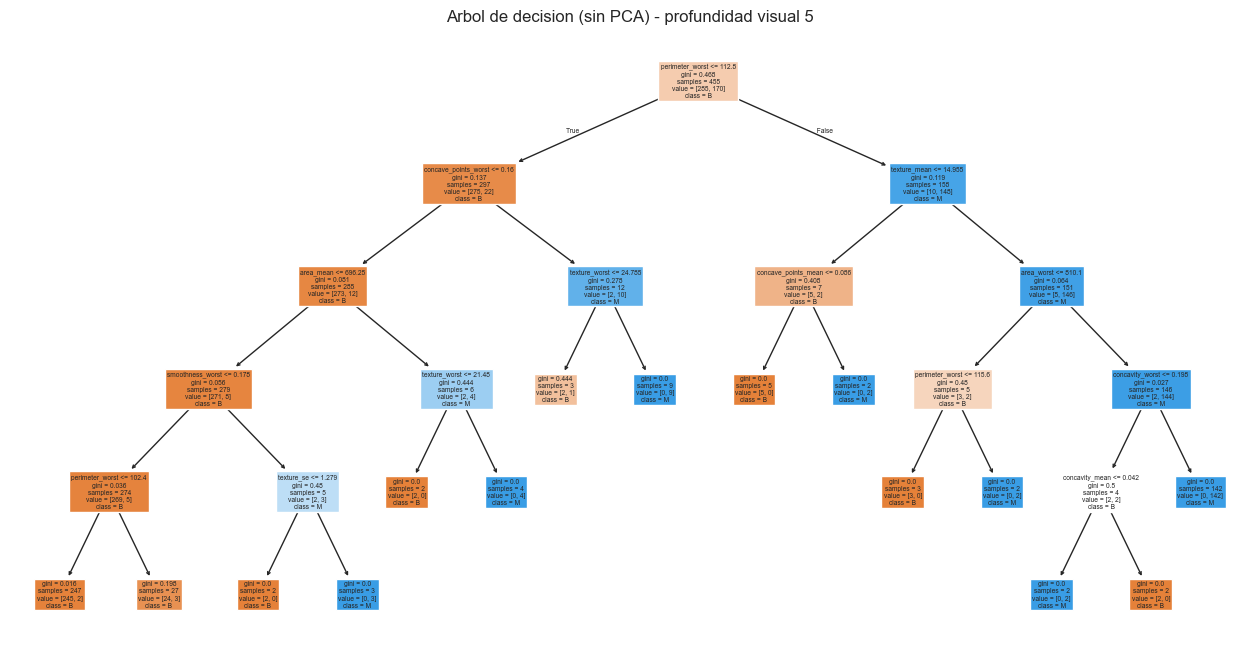

In [25]:
# 7.3.3 Visualizacion del arbol (sin PCA)
plt.figure(figsize=(16, 8))
plot_tree(dt_sin, feature_names=feature_names, class_names=['B', 'M'], filled=True, max_depth=5)
plt.title('Arbol de decision (sin PCA) - profundidad visual 5')
plt.show()


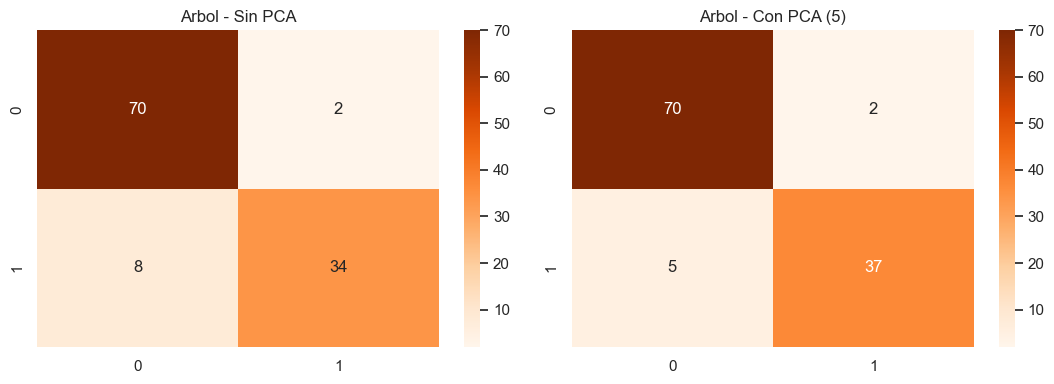

In [ ]:
# 7.3.4 Matrices de confusion - Arbol
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes, [pred_dt_sin, pred_dt_pca], ['Sin PCA', 'Con PCA (5)']):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Oranges', ax=ax)
    ax.set_title(f'Arbol - {title}')
plt.tight_layout(); plt.show()


**Interpretacion Arbol:** alta interpretabilidad por reglas; riesgo de sobreajuste si `max_depth` es muy alto.


### 7.1.4) Modelo: Random Forest

**Guia metodologica:** `segunda_entrega_16_05/Random_Forest_Cancer_PCA.ipynb` y `Clases/08_Mineria_Datos_Random_Forest_Comparacion_Modelos.ipynb`

### Pasos de esta seccion
1. Baseline sin PCA
2. Sensibilidad a `n_estimators`
3. Modelo con PCA
4. Comparacion sin vs con PCA


In [ ]:
# 7.4.1 Random Forest sin PCA
rf_sin = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_sin.fit(X_train, y_train)
pred_rf_sin = rf_sin.predict(X_test)
res_rf_sin = registrar_clasificacion(evaluar_clasificacion('RF - Sin PCA', y_test, pred_rf_sin))
res_rf_sin


{'modelo': 'RF - Sin PCA',
 'accuracy': 0.9649122807017544,
 'precision': 1.0,
 'recall': 0.9047619047619048,
 'f1': 0.95}

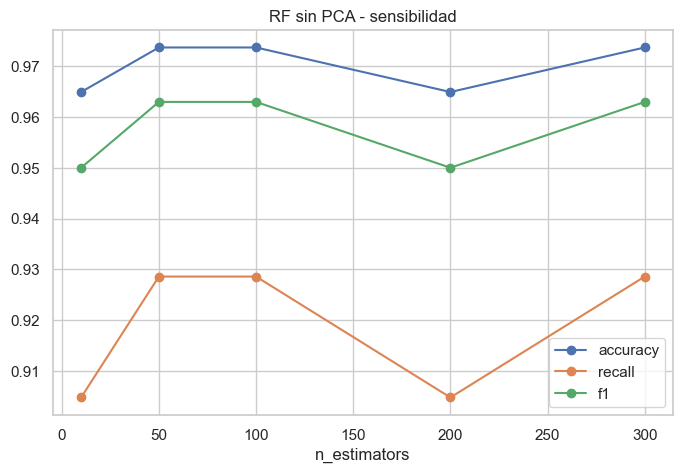

,n_estimators,modelo,accuracy,precision,recall,f1
0,10,tmp,0.964912,1.0,0.904762,0.950000
1,50,tmp,0.973684,1.0,0.928571,0.962963
2,100,tmp,0.973684,1.0,0.928571,0.962963
3,200,tmp,0.964912,1.0,0.904762,0.950000
4,300,tmp,0.973684,1.0,0.928571,0.962963


In [ ]:
# 7.4.2 Sensibilidad a n_estimators
vals = [10, 50, 100, 200, 300]
rows_rf = []
for n in vals:
    m = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows_rf.append({'n_estimators': n, **evaluar_clasificacion('tmp', y_test, p)})
df_rf_sens = pd.DataFrame(rows_rf)
df_rf_sens.plot(x='n_estimators', y=['accuracy', 'recall', 'f1'], marker='o', figsize=(8, 5), title='RF sin PCA - sensibilidad')
plt.grid(True); plt.show()
df_rf_sens


El modelo alcanza sus picos de rendimiento más altos de forma estable en n_estimators = 50 y n_estimators = 100, y vuelve a recuperarse en 300. En estos puntos dulces, el Accuracy roza el 97.4% y el Recall llega a su máximo para este modelo con un 92.8%

In [ ]:
# 7.4.3 Random Forest con PCA
rf_pca = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
pred_rf_pca = rf_pca.predict(X_test_pca)
res_rf_pca = registrar_clasificacion(evaluar_clasificacion('RF - Con PCA (5)', y_test, pred_rf_pca))
pd.DataFrame([res_rf_sin, res_rf_pca])


,modelo,accuracy,precision,recall,f1
0,RF - Sin PCA,0.964912,1.000000,0.904762,0.950000
1,RF - Con PCA (5),0.956140,0.974359,0.904762,0.938272


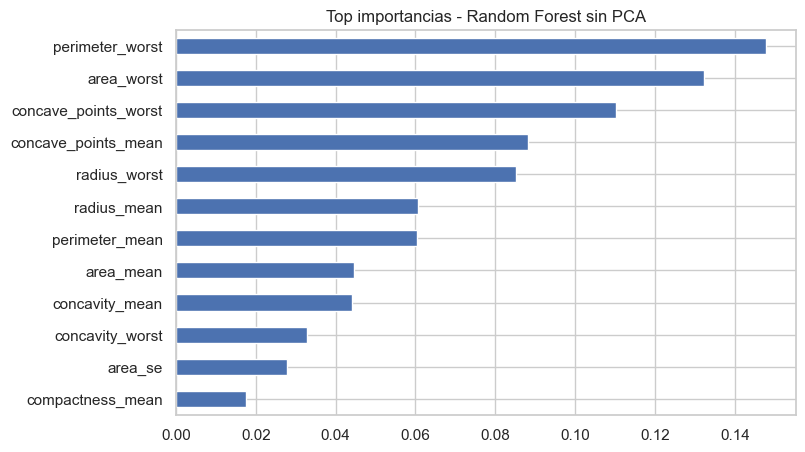

In [ ]:
# 7.4.4 Importancia de variables (sin PCA)
imp = pd.Series(rf_sin.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)
imp.plot(kind='barh', figsize=(8, 5), title='Top importancias - Random Forest sin PCA')
plt.gca().invert_yaxis(); plt.show()


Esta gráfica de Importancia de Características


### 7.1.5) Modelo: SVM

**Guia metodologica:** `Clases/14_SVM_Notebook_Autonomo.ipynb`

### Pasos de esta seccion
1. Definir pipeline con escalado
2. Entrenar SVM RBF (`C=1`, `gamma=scale`)
3. Evaluar metricas y matriz de confusion
4. Comparar sin PCA vs con PCA


In [ ]:
# 7.5.1 SVM sin PCA
svm_sin = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])
svm_sin.fit(X_train, y_train)
pred_svm_sin = svm_sin.predict(X_test)
res_svm_sin = registrar_clasificacion(evaluar_clasificacion('SVM - Sin PCA', y_test, pred_svm_sin))
res_svm_sin


{'modelo': 'SVM - Sin PCA',
 'accuracy': 0.9736842105263158,
 'precision': 1.0,
 'recall': 0.9285714285714286,
 'f1': 0.9629629629629629}

In [ ]:
# 7.5.2 SVM con PCA
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_pca.fit(X_train_pca, y_train)
pred_svm_pca = svm_pca.predict(X_test_pca)
res_svm_pca = registrar_clasificacion(evaluar_clasificacion('SVM - Con PCA (5)', y_test, pred_svm_pca))
pd.DataFrame([res_svm_sin, res_svm_pca])


,modelo,accuracy,precision,recall,f1
0,SVM - Sin PCA,0.973684,1.000,0.928571,0.962963
1,SVM - Con PCA (5),0.964912,0.975,0.928571,0.951220


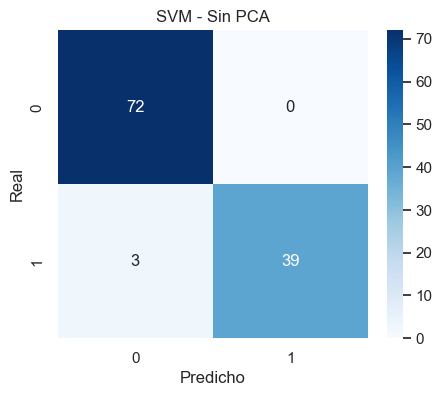

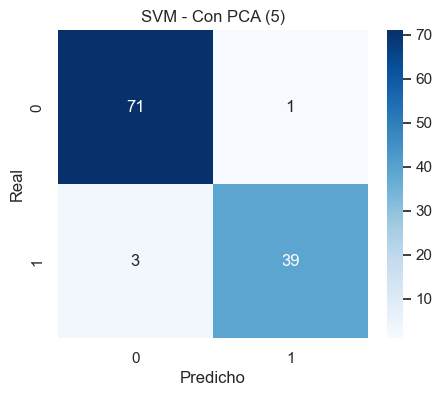

In [33]:
plot_matriz_confusion(y_test, pred_svm_sin, 'SVM - Sin PCA')
plot_matriz_confusion(y_test, pred_svm_pca, 'SVM - Con PCA (5)')


**Interpretacion SVM:** efectivo en fronteras no lineales; costo computacional mayor y sensibilidad a escalado.


### 7.1.6) Modelo: Naive Bayes (Gaussiano)

**Guia metodologica:** `Clases/15__Naive_Bayes_Notebook_Autonomo.ipynb`

### Pasos de esta seccion
1. Entrenar GaussianNB
2. Evaluar metricas sin/con PCA
3. Matrices de confusion


In [34]:
# 12.1 Naive Bayes sin PCA
nb_sin = GaussianNB()
nb_sin.fit(X_train, y_train)
pred_nb_sin = nb_sin.predict(X_test)
res_nb_sin = registrar_clasificacion(evaluar_clasificacion('Naive Bayes - Sin PCA', y_test, pred_nb_sin))

# 12.2 Naive Bayes con PCA
nb_pca = GaussianNB()
nb_pca.fit(X_train_pca, y_train)
pred_nb_pca = nb_pca.predict(X_test_pca)
res_nb_pca = registrar_clasificacion(evaluar_clasificacion('Naive Bayes - Con PCA (5)', y_test, pred_nb_pca))

pd.DataFrame([res_nb_sin, res_nb_pca])


,modelo,accuracy,precision,recall,f1
0,Naive Bayes - Sin PCA,0.938596,1.000000,0.833333,0.909091
1,Naive Bayes - Con PCA (5),0.903509,0.918919,0.809524,0.860759


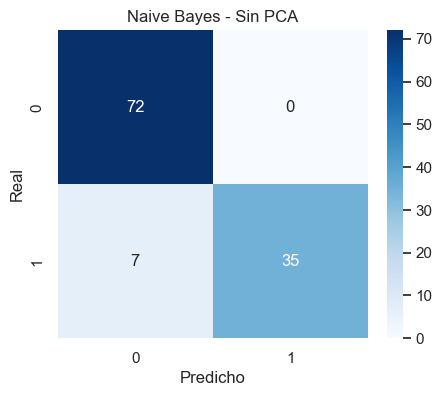

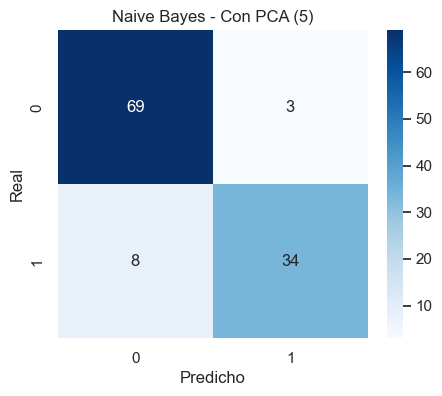

In [35]:
plot_matriz_confusion(y_test, pred_nb_sin, 'Naive Bayes - Sin PCA')
plot_matriz_confusion(y_test, pred_nb_pca, 'Naive Bayes - Con PCA (5)')


**Interpretacion Naive Bayes:** rapido y simple; asume independencia condicional, por lo que puede quedar por debajo de modelos mas flexibles.


## 7.2) Preparacion para modelos de regresion

Siguiendo `segunda_entrega_16_05/Regresion_PCA_Cancer.ipynb`, se predice `area_worst` usando el resto de variables numericas (sin `diagnosis` ni `id`).


In [36]:
reg_target = 'area_worst'
X_reg = work.drop(columns=[reg_target, 'diagnosis', 'id'], errors='ignore')
y_reg = work[reg_target]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

pca_reg = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_train_reg_pca = pca_reg.fit_transform(X_train_reg_scaled)
X_test_reg_pca = pca_reg.transform(X_test_reg_scaled)

print('Regresion train:', X_train_reg.shape)


Regresion train: (455, 29)


## 7.2.1) Modelo de regresion: Regresion Lineal

**Guia:** `segunda_entrega_16_05/Regresion_PCA_Cancer.ipynb`

Pasos: entrenar sin PCA -> entrenar con PCA -> comparar MAE/MSE/RMSE/R2 -> interpretar.


In [37]:
m = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
m.fit(X_train_reg, y_train_reg)
p = m.predict(X_test_reg)
r = evaluar_regresion('Lineal - Sin PCA', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Lineal - Sin PCA,21.264135,1264.481894,35.559554,0.996186


In [38]:
m = LinearRegression().fit(X_train_reg_pca, y_train_reg)
p = m.predict(X_test_reg_pca)
r = evaluar_regresion('Lineal - Con PCA (5)', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Lineal - Con PCA (5),82.666314,20328.607091,142.578424,0.938684


**Interpretacion:** modelo lineal base; util para interpretar tendencia global del tamano tumoral.

## 7.2.2) Modelo de regresion: Ridge

**Guia:** `Clases/07_Mineria_Datos_Regresion.ipynb`

Pasos: entrenar sin PCA -> entrenar con PCA -> comparar MAE/MSE/RMSE/R2 -> interpretar.


In [39]:
m = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))])
m.fit(X_train_reg, y_train_reg)
p = m.predict(X_test_reg)
r = evaluar_regresion('Ridge - Sin PCA', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Ridge - Sin PCA,23.50474,1611.443718,40.142792,0.995139


In [40]:
m = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_reg_pca, y_train_reg)
p = m.predict(X_test_reg_pca)
r = evaluar_regresion('Ridge - Con PCA (5)', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Ridge - Con PCA (5),82.63686,20332.608436,142.592456,0.938671


**Interpretacion:** penaliza coeficientes grandes y ayuda con multicolinealidad.

## 7.2.3) Modelo de regresion: Lasso

**Guia:** `Clases/07_Mineria_Datos_Regresion.ipynb`

Pasos: entrenar sin PCA -> entrenar con PCA -> comparar MAE/MSE/RMSE/R2 -> interpretar.


In [41]:
m = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000))])
m.fit(X_train_reg, y_train_reg)
p = m.predict(X_test_reg)
r = evaluar_regresion('Lasso - Sin PCA', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Lasso - Sin PCA,21.173122,1263.606307,35.547241,0.996189


In [42]:
m = Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000).fit(X_train_reg_pca, y_train_reg)
p = m.predict(X_test_reg_pca)
r = evaluar_regresion('Lasso - Con PCA (5)', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Lasso - Con PCA (5),82.664894,20328.589622,142.578363,0.938684


**Interpretacion:** puede reducir coeficientes a cero (seleccion implicita de variables).

## 7.2.4) Modelo de regresion: Arbol de Regresion

**Guia:** `segunda_entrega_16_05/Regresion_PCA_Cancer.ipynb`

Pasos: entrenar sin PCA -> entrenar con PCA -> comparar MAE/MSE/RMSE/R2 -> interpretar.


In [43]:
m = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
m.fit(X_train_reg, y_train_reg)
p = m.predict(X_test_reg)
r = evaluar_regresion('Arbol Regresion - Sin PCA', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Arbol Regresion - Sin PCA,30.595173,4991.119623,70.647856,0.984945


In [44]:
m = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
m.fit(X_train_reg_pca, y_train_reg)
p = m.predict(X_test_reg_pca)
r = evaluar_regresion('Arbol Regresion - Con PCA (5)', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,Arbol Regresion - Con PCA (5),130.305007,49831.963315,223.23074,0.849694


**Interpretacion:** captura no linealidades, pero puede sobreajustar sin poda adecuada.

## 7.2.5) Modelo de regresion: Random Forest (Regresion)

**Guia:** `segunda_entrega_16_05/Random_Forest_Cancer_PCA.ipynb`

Pasos: entrenar sin PCA -> entrenar con PCA -> comparar MAE/MSE/RMSE/R2 -> interpretar.


In [45]:
m = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
m.fit(X_train_reg, y_train_reg)
p = m.predict(X_test_reg)
r = evaluar_regresion('RF Regresion - Sin PCA', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,RF Regresion - Sin PCA,26.288327,4169.686532,64.57311,0.987423


In [46]:
m = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
m.fit(X_train_reg_pca, y_train_reg)
p = m.predict(X_test_reg_pca)
r = evaluar_regresion('RF Regresion - Con PCA (5)', y_test_reg, p)
resultados_regresion.append(r)
pd.DataFrame([r])

,modelo,MAE,MSE,RMSE,R2
0,RF Regresion - Con PCA (5),77.897249,17801.018384,133.420457,0.946307


**Interpretacion:** en general robusto para relaciones no lineales en regresion.

# 8) Modelos No Supervisados

## 8.1) Modelo no supervisado: KMeans

**Guia:** `Clases/12_Clustering_Jerarquico_DBSCAN_.ipynb`

Pasos: escalar datos -> KMeans k=2 -> silhouette y Dunn -> visualizar en PCA.


KMeans -> silhouette: 0.345 | dunn: 0.0608


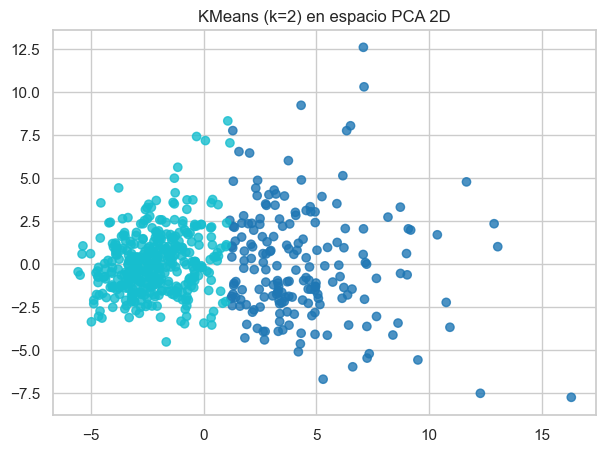

In [47]:
X_unsup = work.drop(columns=['diagnosis', 'id'], errors='ignore')
X_unsup_scaled = StandardScaler().fit_transform(X_unsup)
X_unsup_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_unsup_scaled)

kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20)
labels_kmeans = kmeans.fit_predict(X_unsup_scaled)

sil_k = silhouette_score(X_unsup_scaled, labels_kmeans)

def dunn_index(X, labels):
    ul = np.unique(labels)
    ul = ul[ul != -1]
    if len(ul) < 2:
        return np.nan
    clusters = [X[labels == l] for l in ul]
    min_inter = np.inf
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            d = pairwise_distances(clusters[i], clusters[j])
            min_inter = min(min_inter, d.min())
    max_intra = 0
    for c in clusters:
        if len(c) > 1:
            d = pairwise_distances(c, c)
            max_intra = max(max_intra, d.max())
    return np.nan if max_intra == 0 else min_inter / max_intra

dunn_k = dunn_index(X_unsup_scaled, labels_kmeans)
resultados_clustering.append({'modelo': 'KMeans_k2', 'silhouette': sil_k, 'dunn': dunn_k})
print('KMeans -> silhouette:', round(sil_k, 4), '| dunn:', round(dunn_k, 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_unsup_pca2[:, 0], X_unsup_pca2[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.8)
plt.title('KMeans (k=2) en espacio PCA 2D')
plt.show()


## 8.2) Modelo no supervisado: Clustering Jerarquico

**Guia:** `Clases/12_Clustering_Jerarquico_DBSCAN_.ipynb`


Jerarquico -> silhouette: 0.3394 | dunn: 0.0724


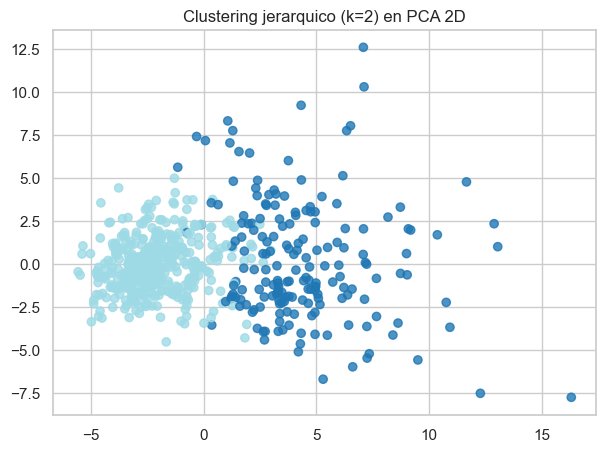

In [48]:
jer = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_jer = jer.fit_predict(X_unsup_scaled)
sil_j = silhouette_score(X_unsup_scaled, labels_jer)
dunn_j = dunn_index(X_unsup_scaled, labels_jer)
resultados_clustering.append({'modelo': 'Jerarquico_k2', 'silhouette': sil_j, 'dunn': dunn_j})
print('Jerarquico -> silhouette:', round(sil_j, 4), '| dunn:', round(dunn_j, 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_unsup_pca2[:, 0], X_unsup_pca2[:, 1], c=labels_jer, cmap='tab20', alpha=0.8)
plt.title('Clustering jerarquico (k=2) en PCA 2D')
plt.show()


## 8.3) Modelo no supervisado: DBSCAN

**Guia:** `Clases/12_Clustering_Jerarquico_DBSCAN_.ipynb` y metrica Dunn de `Clases/16_Dunn_Correspondence_Analysis.ipynb`


DBSCAN -> silhouette: 0.38999488783902264 | dunn: 0.3122494022401153 | ruido: 345


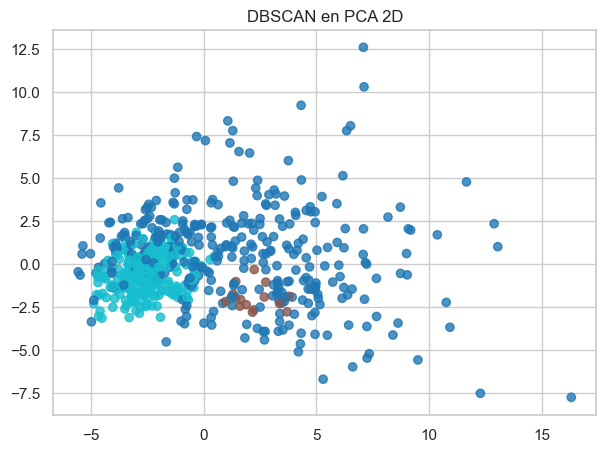

In [49]:
db = DBSCAN(eps=2.2, min_samples=8)
labels_db = db.fit_predict(X_unsup_scaled)
mask = labels_db != -1
if len(np.unique(labels_db[mask])) > 1:
    sil_db = silhouette_score(X_unsup_scaled[mask], labels_db[mask])
else:
    sil_db = np.nan
dunn_db = dunn_index(X_unsup_scaled, labels_db)
ruido = int((labels_db == -1).sum())
resultados_clustering.append({'modelo': 'DBSCAN', 'silhouette': sil_db, 'dunn': dunn_db, 'ruido': ruido})
print('DBSCAN -> silhouette:', sil_db, '| dunn:', dunn_db, '| ruido:', ruido)

plt.figure(figsize=(7, 5))
plt.scatter(X_unsup_pca2[:, 0], X_unsup_pca2[:, 1], c=labels_db, cmap='tab10', alpha=0.8)
plt.title('DBSCAN en PCA 2D')
plt.show()


**Interpretacion clustering:** KMeans y jerarquico asumen grupos compactos; DBSCAN detecta ruido y formas arbitrarias segun `eps` y `min_samples`.


## 9-10) Evaluacion y comparacion global de modelos

Se consolidan resultados de clasificacion, regresion y clustering para seleccionar el mejor enfoque segun metricas y contexto clinico.


In [50]:
cls_df = pd.DataFrame(resultados_clasificacion).sort_values('f1', ascending=False).reset_index(drop=True)
reg_df = pd.DataFrame(resultados_regresion).sort_values('RMSE').reset_index(drop=True)
clu_df = pd.DataFrame(resultados_clustering).sort_values('silhouette', ascending=False).reset_index(drop=True)

print('=== CLASIFICACION ===')
display(cls_df)
print('=== REGRESION ===')
display(reg_df)
print('=== CLUSTERING ===')
display(clu_df)

best_cls = cls_df.iloc[0]
best_reg = reg_df.iloc[0]
best_clu = clu_df.iloc[0]

print('\nMejor clasificacion (F1):', best_cls['modelo'], '- F1=', round(best_cls['f1'], 4))
print('Mejor regresion (RMSE):', best_reg['modelo'], '- RMSE=', round(best_reg['RMSE'], 2))
print('Mejor clustering (Silhouette):', best_clu['modelo'])


=== CLASIFICACION ===


,modelo,accuracy,precision,recall,f1
0,Logistica - Con PCA (5),0.973684,0.975610,0.952381,0.963855
1,SVM - Sin PCA,0.973684,1.000000,0.928571,0.962963
2,SVM - Con PCA (5),0.964912,0.975000,0.928571,0.951220
3,Logistica - Sin PCA,0.964912,0.975000,0.928571,0.951220
4,RF - Sin PCA,0.964912,1.000000,0.904762,0.950000
5,KNN - Sin PCA,0.956140,0.974359,0.904762,0.938272
6,RF - Con PCA (5),0.956140,0.974359,0.904762,0.938272
7,KNN - Con PCA (5),0.947368,0.973684,0.880952,0.925000
8,Arbol - Con PCA (5),0.938596,0.948718,0.880952,0.913580
9,Naive Bayes - Sin PCA,0.938596,1.000000,0.833333,0.909091


=== REGRESION ===


,modelo,MAE,MSE,RMSE,R2
0,Lasso - Sin PCA,21.173122,1263.606307,35.547241,0.996189
1,Lineal - Sin PCA,21.264135,1264.481894,35.559554,0.996186
2,Ridge - Sin PCA,23.504740,1611.443718,40.142792,0.995139
3,RF Regresion - Sin PCA,26.288327,4169.686532,64.573110,0.987423
4,Arbol Regresion - Sin PCA,30.595173,4991.119623,70.647856,0.984945
5,RF Regresion - Con PCA (5),77.897249,17801.018384,133.420457,0.946307
6,Lasso - Con PCA (5),82.664894,20328.589622,142.578363,0.938684
7,Lineal - Con PCA (5),82.666314,20328.607091,142.578424,0.938684
8,Ridge - Con PCA (5),82.636860,20332.608436,142.592456,0.938671
9,Arbol Regresion - Con PCA (5),130.305007,49831.963315,223.230740,0.849694


=== CLUSTERING ===


,modelo,silhouette,dunn,ruido
0,DBSCAN,0.389995,0.312249,345.0
1,KMeans_k2,0.344974,0.060763,NaN
2,Jerarquico_k2,0.339385,0.072388,NaN



Mejor clasificacion (F1): Logistica - Con PCA (5) - F1= 0.9639
Mejor regresion (RMSE): Lasso - Sin PCA - RMSE= 35.55
Mejor clustering (Silhouette): DBSCAN


## 11) Mejor modelo y justificacion

### Clasificacion
Regresion Logistica - Con PCA (5) : recall 0.975610	F1 0.952381

Se prioriza **F1 y recall** para reducir falsos negativos en clase maligna (`M`).

### Regresion
Lasso - Sin PCAR: MSE 35.547241	R2 0.996189

Se selecciona por menor **RMSE** y mayor **R2** en la tarea de `area_worst`.

### No supervisado
DBSCAN	0.389995	0.312249

Se usa silhouette y Dunn para comparar estructura interna; no reemplaza el diagnostico supervisado.


## 12) Conclusiones

1. Hallazgos Relevantes
- los datos demostraron ser linealmente separables en el espacio de componentes principales. Esto permitió que la Regresión Logística con PCA (5) superara a algoritmos más complejos (como Random Forest o SVM no lineal), logrando el mejor equilibrio clínico para minimizar los falsos negativos ($Recall = 0.952$).
- La reducción de dimensionalidad demostró ser un arma de doble filo según la tarea. Mientras que en la clasificación optimizó la frontera de decisión al eliminar el ruido, en la regresión destruyó el rendimiento. Modelos como Lasso y Lineal pasaron de un $R^2$ casi perfecto (0.996) a un 0.938 con PCA. 
2. Limitaciones
- Al implementar PCA para el modelo campeón de clasificación, se pierde la trazabilidad directa de las variables. Explicar a un profesional de la salud que un tumor es maligno debido a una "alta puntuación en PC1" es menos intuitivo que hablar del perímetro o la concavidad real de la célula.
- El modelo fue entrenado con una cantidad relativamente pequeña de pacientes y un desbalance moderado (62% Benigno vs. 37% Maligno). Esto restringe la capacidad del modelo para generalizar ante casos atípicos o variaciones demográficas más amplias.
3. Posibles Mejoras Futuras
- Dado que las variables tabulares provienen de imágenes digitalizadas (FNA), el siguiente paso evolutivo sería entrenar Redes Neuronales Convolucionales (CNN) directamente sobre las fotografías de las biopsias, eliminando el sesgo de la extracción manual de características geométricas.
- Aplicar técnicas de sobremuestreo sintético como SMOTE (Synthetic Minority Over-sampling Technique) en la clase maligna durante el entrenamiento, o recolectar un volumen mayor de datos clínicos, para robustecer las fronteras de decisión y acercar la métrica de Recall al 100%.
